# WTA Match Predictor - Model Training

## Contents

- Import Data and Packages
- Preprocessing and Defining Features
- Train, Test, and Evaluate Models

### Import Data and Required Packages

In [34]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns # for scrambling columns
import random
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [35]:
df = pd.read_csv('data/stud.csv')
df.head()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2023-609,Indian Wells,Hard,96,PM,20230306,286,214544,2.0,NaN,...,58,37,16,13,8,11,2,6100,16,2205
1,2023-609,Indian Wells,Hard,96,PM,20230306,285,216347,1.0,NaN,...,55,30,4,10,3,8,1,10585,36,1303
2,2023-609,Indian Wells,Hard,96,PM,20230306,284,221054,NaN,NaN,...,52,37,10,12,5,8,77,784,13,2246
3,2023-609,Indian Wells,Hard,96,PM,20230306,283,201514,NaN,NaN,...,24,14,12,8,0,5,83,743,43,1200
4,2023-609,Indian Wells,Hard,96,PM,20230306,282,201614,5.0,NaN,...,50,34,21,14,1,4,5,4905,49,1080


### Preprocessing and Defining Features

In [36]:
# First, we want to drop columns that we know will not be useful for our model or understanding.
# Information related to the tournament is not relevant
df.drop(columns=['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level', 'tourney_date'], axis=1, inplace=True)
# Certain information about players (e.g. height, age, hand) are also irrelevant
df.drop(columns=['winner_hand', 'loser_hand', 'winner_ht', 'loser_ht', 'winner_age', 'loser_age', 'winner_ioc', 'loser_ioc'], axis=1, inplace=True)
# Certain match information will also be irrelevant for predictions
df.drop(columns=['match_num', 'best_of', 'round', 'minutes', 'score'], axis=1, inplace=True)
# For now, we will also drop most columns outside of statistics, although we may use some of these in future iterations
df.drop(columns=['winner_seed', 'loser_seed', 'winner_entry', 'loser_entry', 'winner_rank', 'loser_rank', 'winner_rank_points', 'loser_rank_points'], axis=1, inplace=True)
# We will also drop 'bp_saved' for both players, since we found this was not a meaningful statistic in our EDA
df.drop(columns=['w_bpSaved', 'l_bpSaved'], axis=1, inplace=True)
# Finally, drop observations with NaN values
df.dropna()

,winner_id,winner_name,loser_id,loser_name,w_ace,w_df,w_svpt,w_1stIn,w_1stWon,w_2ndWon,w_SvGms,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpFaced
0,214544,Aryna Sabalenka,206252,Barbora Krejcikova,11,4,84,53,39,12,14,4,3,6,88,58,37,16,13,11
1,216347,Iga Swiatek,215370,Bianca Andreescu,1,0,73,50,31,10,11,8,1,2,72,55,30,4,10,8
2,221054,Emma Raducanu,206242,Beatriz Haddad Maia,2,4,83,55,38,14,13,5,4,4,76,52,37,10,12,8
3,201514,Sorana Cirstea,211095,Bernarda Pera,4,0,44,22,19,12,8,1,3,5,55,24,14,12,8,5
4,201614,Caroline Garcia,220367,Leylah Fernandez,11,3,93,49,42,26,15,2,5,8,91,50,34,21,14,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,214643,Liudmila Samsonova,214247,Lena Rueffer,11,10,147,71,54,40,18,14,1,2,118,85,59,17,18,9
108,201520,Petra Kvitova,202499,Donna Vekic,8,5,73,49,36,12,10,5,7,3,59,42,32,5,10,4
109,201520,Petra Kvitova,206420,Ekaterina Alexandrova,4,4,63,35,27,17,10,0,0,2,55,34,25,12,9,6
110,202499,Donna Vekic,206289,Maria Sakkari,5,6,92,52,36,17,11,11,5,2,94,60,38,15,11,11


In [37]:
df.head()

,winner_id,winner_name,loser_id,loser_name,w_ace,w_df,w_svpt,w_1stIn,w_1stWon,w_2ndWon,w_SvGms,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpFaced
0,214544,Aryna Sabalenka,206252,Barbora Krejcikova,11,4,84,53,39,12,14,4,3,6,88,58,37,16,13,11
1,216347,Iga Swiatek,215370,Bianca Andreescu,1,0,73,50,31,10,11,8,1,2,72,55,30,4,10,8
2,221054,Emma Raducanu,206242,Beatriz Haddad Maia,2,4,83,55,38,14,13,5,4,4,76,52,37,10,12,8
3,201514,Sorana Cirstea,211095,Bernarda Pera,4,0,44,22,19,12,8,1,3,5,55,24,14,12,8,5
4,201614,Caroline Garcia,220367,Leylah Fernandez,11,3,93,49,42,26,15,2,5,8,91,50,34,21,14,4


Something very important to note is that, if we implicitly define matches as already having a winner and loser, our model will always predict the match outcome with 100% accuracy, since the data will always indicate who wins and who loses. To fix this, we need to scramble the columns for winners and losers, so it's not obvious to the model who wins the match. We will also rename columns so that there is no mention of a winner or a loser, and will instead encode winner/loser as a single number, 0 (for player 1) or 1 (for player 2).

In [38]:
# First: Rename 'winner_'/'w_' and 'loser_'/'l_' columns to represent player 1 and player 2 respectively
for col in df.columns:
    if 'winner' in col:
        df.rename(columns={col: col.replace('winner', 'p1')}, inplace=True)
    elif 'w' in col:
        df.rename(columns={col: col.replace('w', 'p1')}, inplace=True)
    elif 'loser' in col:
        df.rename(columns={col: col.replace('loser', 'p2')}, inplace=True)
    elif 'l' in col:
        df.rename(columns={col: col.replace('l', 'p2')}, inplace=True)
df['match_winner'] = 0 # create match winner column with all 0s (player 1 for all obs.)

In [39]:
df.head()

,p1_id,p1_name,p2_id,p2_name,p1_ace,p1_df,p1_svpt,p1_1stIn,p1_1stWon,p1_2ndWon,...,p1_bpFaced,p2_ace,p2_df,p2_svpt,p2_1stIn,p2_1stWon,p2_2ndWon,p2_SvGms,p2_bpFaced,match_winner
0,214544,Aryna Sabalenka,206252,Barbora Krejcikova,11,4,84,53,39,12,...,4,3,6,88,58,37,16,13,11,0
1,216347,Iga Swiatek,215370,Bianca Andreescu,1,0,73,50,31,10,...,8,1,2,72,55,30,4,10,8,0
2,221054,Emma Raducanu,206242,Beatriz Haddad Maia,2,4,83,55,38,14,...,5,4,4,76,52,37,10,12,8,0
3,201514,Sorana Cirstea,211095,Bernarda Pera,4,0,44,22,19,12,...,1,3,5,55,24,14,12,8,5,0
4,201614,Caroline Garcia,220367,Leylah Fernandez,11,3,93,49,42,26,...,2,5,8,91,50,34,21,14,4,0


In [40]:
# Second: Randomly shuffle p1 and p2 columns to ensure no pattern
cols1 = [c for c in df.columns if 'p1' in c]
cols2 = [c for c in df.columns if 'p2' in c]
cols2_targ = [c.replace('p1', 'p2') for c in cols1]
print(cols1)
print(cols2)

# copy df for scrambling
copy = df.copy()

#maskIdx = [i for i in df.index if i % 3]
# generate len(df.index) / 2 random indices. for those observations, swap columns and set match_winner to 1
maskIdx = [random.randint(0, len(df.index) - 1) for i in range((int)(len(df.index) / 2))]
print(maskIdx)
df.loc[maskIdx, cols1] = copy.loc[maskIdx, cols2_targ].values
df.loc[maskIdx, cols2_targ] = copy.loc[maskIdx, cols1].values
df.loc[maskIdx, 'match_winner'] = 1

['p1_id', 'p1_name', 'p1_ace', 'p1_df', 'p1_svpt', 'p1_1stIn', 'p1_1stWon', 'p1_2ndWon', 'p1_SvGms', 'p1_bpFaced']
['p2_id', 'p2_name', 'p2_ace', 'p2_df', 'p2_svpt', 'p2_1stIn', 'p2_1stWon', 'p2_2ndWon', 'p2_SvGms', 'p2_bpFaced']
[37, 4, 21, 29, 61, 101, 51, 32, 68, 84, 108, 44, 97, 17, 6, 53, 87, 4, 97, 7, 79, 55, 3, 65, 79, 34, 84, 69, 60, 18, 105, 18, 58, 86, 73, 101, 95, 11, 52, 3, 59, 46, 9, 84, 56, 23, 81, 67, 13, 29, 89, 3, 84, 7, 8, 90]


In [41]:
# By running all the cells in this notebook, you can see that the columns are randomly shuffled, indicated by the match winner changing between 0 and 1 for different observations.
df.head(10)

,p1_id,p1_name,p2_id,p2_name,p1_ace,p1_df,p1_svpt,p1_1stIn,p1_1stWon,p1_2ndWon,...,p1_bpFaced,p2_ace,p2_df,p2_svpt,p2_1stIn,p2_1stWon,p2_2ndWon,p2_SvGms,p2_bpFaced,match_winner
0,214544,Aryna Sabalenka,206252,Barbora Krejcikova,11,4,84,53,39,12,...,4,3,6,88,58,37,16,13,11,0
1,216347,Iga Swiatek,215370,Bianca Andreescu,1,0,73,50,31,10,...,8,1,2,72,55,30,4,10,8,0
2,221054,Emma Raducanu,206242,Beatriz Haddad Maia,2,4,83,55,38,14,...,5,4,4,76,52,37,10,12,8,0
3,211095,Bernarda Pera,201514,Sorana Cirstea,3,5,55,24,14,12,...,5,4,0,44,22,19,12,8,1,1
4,220367,Leylah Fernandez,201614,Caroline Garcia,5,8,91,50,34,21,...,4,11,3,93,49,42,26,15,2,1
5,214954,Marketa Vondrousova,202460,Ons Jabeur,0,5,68,37,23,17,...,4,2,2,71,37,25,10,11,8,0
6,203354,Martina Trevisan,214096,Karolina Muchova,0,4,97,65,41,17,...,13,7,7,97,58,43,19,15,8,1
7,211651,Paula Badosa,214981,Elena Rybakina,2,7,63,34,23,13,...,8,9,1,76,44,30,19,10,6,1
8,214096,Karolina Muchova,201514,Sorana Cirstea,3,1,63,40,20,10,...,8,4,1,53,39,26,9,10,4,1
9,201662,Karolina Pliskova,214954,Marketa Vondrousova,2,5,37,26,8,3,...,8,4,3,46,31,23,6,8,6,1


Now that our data is sufficiently preprocessed, we can define our X and y features. `X` will contain all of our input features, while `y` will be our single target output.

In [42]:
# Define X: all columns except p1/p2 name (irrelevant to model) and the match winner
X = df.drop(columns=['p1_name', 'p2_name', 'match_winner'], axis=1)
# Define y: match winner
y = df['match_winner']

In [43]:
X.head()

,p1_id,p2_id,p1_ace,p1_df,p1_svpt,p1_1stIn,p1_1stWon,p1_2ndWon,p1_SvGms,p1_bpFaced,p2_ace,p2_df,p2_svpt,p2_1stIn,p2_1stWon,p2_2ndWon,p2_SvGms,p2_bpFaced
0,214544,206252,11,4,84,53,39,12,14,4,3,6,88,58,37,16,13,11
1,216347,215370,1,0,73,50,31,10,11,8,1,2,72,55,30,4,10,8
2,221054,206242,2,4,83,55,38,14,13,5,4,4,76,52,37,10,12,8
3,211095,201514,3,5,55,24,14,12,8,5,4,0,44,22,19,12,8,1
4,220367,201614,5,8,91,50,34,21,14,4,11,3,93,49,42,26,15,2


Since all of our predictive features are already quantitative, we don't need to worry about encoding any categorical variables. In this case, we can move directly onto modelling.

### Train, Test, and Evaluate Models

In [44]:
# Separate dataset into training and testing sets (80/20 split)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((89, 18), (23, 18))

In [45]:
# Define model evaluation function
# Use built-in functions to find most relevant statistics for model strength and accuracy
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, mse, rmse, r2_square

In [46]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.1882
- Mean Absolute Error: 0.1509
- R2 Score: 0.8482
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.2444
- Mean Absolute Error: 0.2124
- R2 Score: 0.7607


Lasso
Model performance for Training set
- Root Mean Squared Error: 0.4622
- Mean Absolute Error: 0.4437
- R2 Score: 0.0843
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.4938
- Mean Absolute Error: 0.4767
- R2 Score: 0.0229


Ridge
Model performance for Training set
- Root Mean Squared Error: 0.1882
- Mean Absolute Error: 0.1509
- R2 Score: 0.8482
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.2443
- Mean Absolute Error: 0.2121
- R2 Score: 0.7608


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 0.4432
- Mean Absolute Error: 0.3978
- R2 Score: 0.1582
-----------------------

In [47]:
# Visualize results
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.760820
0,Linear Regression,0.760655
5,Random Forest Regressor,0.220457
7,CatBoosting Regressor,0.170252
6,XGBRegressor,0.102995
8,AdaBoost Regressor,0.041374
1,Lasso,0.022926
3,K-Neighbors Regressor,-0.428788
4,Decision Tree,-0.568182


Conclusions:
- Ridge and linear regression models seem to clearly be the best options, with r-squared values over 0.7.
- Interestingly, most other models appear to be very poor at predicting match winners. The other seven models have an r-squared value less than 0.5
    - Two models, the decision tree and k-neighbors regressor, even have negative r-squared values, meaning they predict match winners worse than a horizontal line representing the mean!
    - This may be an issue with how we are representing the data. It could also be due to a lack of preprocessing.

#### Fit and Predict with Best Model: Linear Regression

Our linear regression model produced excellent results and is simple/effective, so we will try this for our predictions.

In [48]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred) * 100
print("Model Accuracy: %.2f" %score + "%")

Model Accuracy: 76.07%


Text(0, 0.5, 'Predicted')

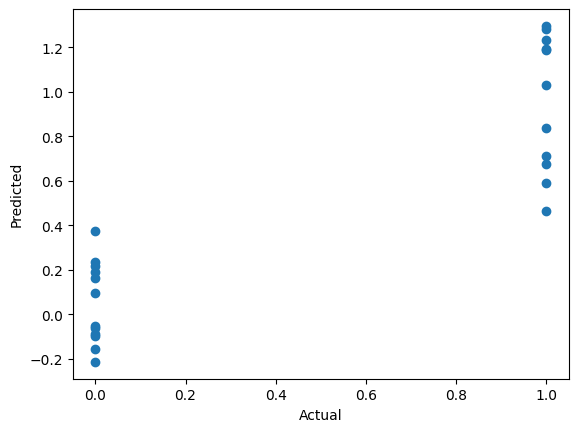

In [49]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

<Axes: xlabel='match_winner'>

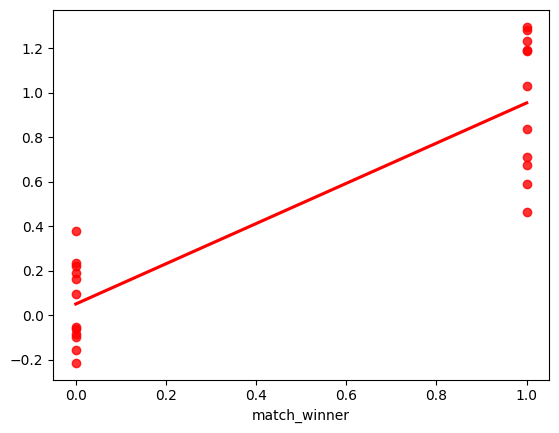

In [50]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red')

In [51]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
40,0,0.188824,-0.188824
65,1,1.193583,-0.193583
4,1,1.189259,-0.189259
47,0,-0.097344,0.097344
42,0,-0.213147,0.213147
69,1,1.231402,-0.231402
26,0,0.376774,-0.376774
11,1,1.281688,-0.281688
10,0,0.219773,-0.219773
44,1,0.465470,0.534530


In [52]:
print("Average difference: " + str(sum(pred_df['Difference']) / len(pred_df['Difference'])))

Average difference: -0.004910466408559672


As you can see, this linear regression model is consistently around 0.07 away from correctly predicting a match winner/loser (0 or 1). Therefore, we can accurately use this model to predict the percentage chance that a player wins a tennis match.